# 07 — Competitor Intelligence
Segmenting the market into tiers and profiling direct competitors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/brick_features_v4.csv')
district = pd.read_csv('../data/processed/brick_location_scores.csv')

# Segment into tiers
def assign_tier(machine_type):
    if machine_type == 'Fully Automatic Machine Made':
        return 'Tier 1 — Fully Automatic'
    elif machine_type == 'Semi Automatic Concrete Machine Made':
        return 'Tier 2 — Semi Automatic'
    elif machine_type == 'Hand Made':
        return 'Tier 3 — Hand Made'
    else:
        return 'Tier 4 — Unknown'

df['competitor_tier'] = df['Machine Type'].apply(assign_tier)

print("=== MARKET TIER BREAKDOWN ===")
tier_summary = df.groupby('competitor_tier').agg(
    count=('Company Name', 'count'),
    running=('is_operational', 'sum'),
    eco_count=('is_eco', 'sum'),
    large_count=('Company Size', lambda x: (x=='Large').sum()),
    has_website=('has_website', 'sum')
).reset_index()

tier_summary['pct_of_market'] = (tier_summary['count'] / len(df) * 100).round(1)
tier_summary['eco_share'] = (tier_summary['eco_count'] / tier_summary['count'] * 100).round(1)
tier_summary['website_share'] = (tier_summary['has_website'] / tier_summary['count'] * 100).round(1)
tier_summary['operational_rate'] = (tier_summary['running'] / tier_summary['count'] * 100).round(1)

print(tier_summary.to_string(index=False))

=== MARKET TIER BREAKDOWN ===
         competitor_tier  count  running  eco_count  large_count  has_website  pct_of_market  eco_share  website_share  operational_rate
Tier 1 — Fully Automatic     64       62         63           54           18           18.0       98.4           28.1              96.9
 Tier 2 — Semi Automatic     76       67         76           15            6           21.4      100.0            7.9              88.2
      Tier 3 — Hand Made    198      169         95           56           22           55.8       48.0           11.1              85.4
        Tier 4 — Unknown     17        5          0            0            1            4.8        0.0            5.9              29.4


In [2]:
tier1 = df[df['competitor_tier'] == 'Tier 1 — Fully Automatic'].copy()

print(f"=== TIER 1 DEEP PROFILE ({len(tier1)} factories) ===\n")

print("District distribution:")
print(tier1['Districts'].value_counts().head(10))

print("\nSize distribution:")
print(tier1['Company Size'].value_counts())

print("\nProduct type:")
print(tier1['Product Type'].value_counts())

print("\nDigital presence:")
print(f"Has website: {tier1['has_website'].sum()} ({tier1['has_website'].mean()*100:.1f}%)")
print(f"Has contact: {tier1['has_contact'].sum()} ({tier1['has_contact'].mean()*100:.1f}%)")

print("\nOperational status:")
print(tier1['Status'].value_counts())

print("\nTop Tier 1 competitors by name:")
print(tier1[['Company Name', 'Districts', 'Company Size', 
             'has_website', 'Status']].to_string(index=False))

=== TIER 1 DEEP PROFILE (64 factories) ===

District distribution:
Districts
Hyderabad              13
Medchal Malkajgiri     10
Siddipet                6
Yadadri Bhuvanagiri     4
Mancherial              3
Karimnagar              3
Nagarkurnool            3
Sangareddy              2
Hanumakonda             2
Suryapet                2
Name: count, dtype: int64

Size distribution:
Company Size
Large       54
Moderate     6
Small        4
Name: count, dtype: int64

Product type:
Product Type
Fly Ash Brick       63
Fired Clay Brick     1
Name: count, dtype: int64

Digital presence:
Has website: 18 (28.1%)
Has contact: 43 (67.2%)

Operational status:
Status
Running               62
Permanently Closed     1
Temporarily Closed     1
Name: count, dtype: int64

Top Tier 1 competitors by name:
                                                                     Company Name               Districts Company Size  has_website             Status
                                                     

In [3]:
# District × Tier matrix
matrix = pd.crosstab(
    df['Districts'], 
    df['competitor_tier'],
    margins=True
).rename(columns={'All': 'Total'})

print("=== COMPETITOR MATRIX: District × Tier ===")
print(matrix.to_string())

=== COMPETITOR MATRIX: District × Tier ===
competitor_tier          Tier 1 — Fully Automatic  Tier 2 — Semi Automatic  Tier 3 — Hand Made  Tier 4 — Unknown  Total
Districts                                                                                                              
Adilabad                                        0                        1                   2                 0      3
Bhadradri Kothagudem                            0                        4                   6                 0     10
Hanumakonda                                     2                        6                  13                 1     22
Hyderabad                                      13                        9                   8                 0     30
Jagtial                                         0                        1                   8                 1     10
Jangaon                                         1                        3                  10                 0     

In [4]:
# Focus on top 3 recommended districts from Phase 7
target_districts = ['Ranga Reddy', 'Kamareddy', 'Peddapalli']

print("=== DIRECT COMPETITORS IN TARGET DISTRICTS ===\n")
for d in target_districts:
    competitors = df[
        (df['Districts'] == d) & 
        (df['is_operational'] == True)
    ][['Company Name', 'competitor_tier', 'Company Size', 
       'Product Type', 'has_website']].sort_values('competitor_tier')
    
    print(f"--- {d} ({len(competitors)} running factories) ---")
    print(competitors.to_string(index=False))
    print()

=== DIRECT COMPETITORS IN TARGET DISTRICTS ===

--- Ranga Reddy (6 running factories) ---
                        Company Name          competitor_tier Company Size     Product Type  has_website
               Supreme Brick Factory Tier 1 — Fully Automatic     Moderate    Fly Ash Brick        False
              SRI SAI BRICK INDUSTRY Tier 1 — Fully Automatic        Large    Fly Ash Brick        False
               Prasuna Cement Bricks  Tier 2 — Semi Automatic     Moderate    Fly Ash Brick        False
               SSB Bricks AAC BLOCKS  Tier 2 — Semi Automatic     Moderate    Fly Ash Brick         True
              SAASTA BRICKS INDUSTRY  Tier 2 — Semi Automatic     Moderate    Fly Ash Brick        False
B L S BRICK MANUFACTURING AND SUPPLY       Tier 3 — Hand Made     Moderate Fired Clay Brick        False

--- Kamareddy (1 running factories) ---
      Company Name    competitor_tier Company Size     Product Type  has_website
KRR BRICKS COMPANY Tier 3 — Hand Made        Large Fi

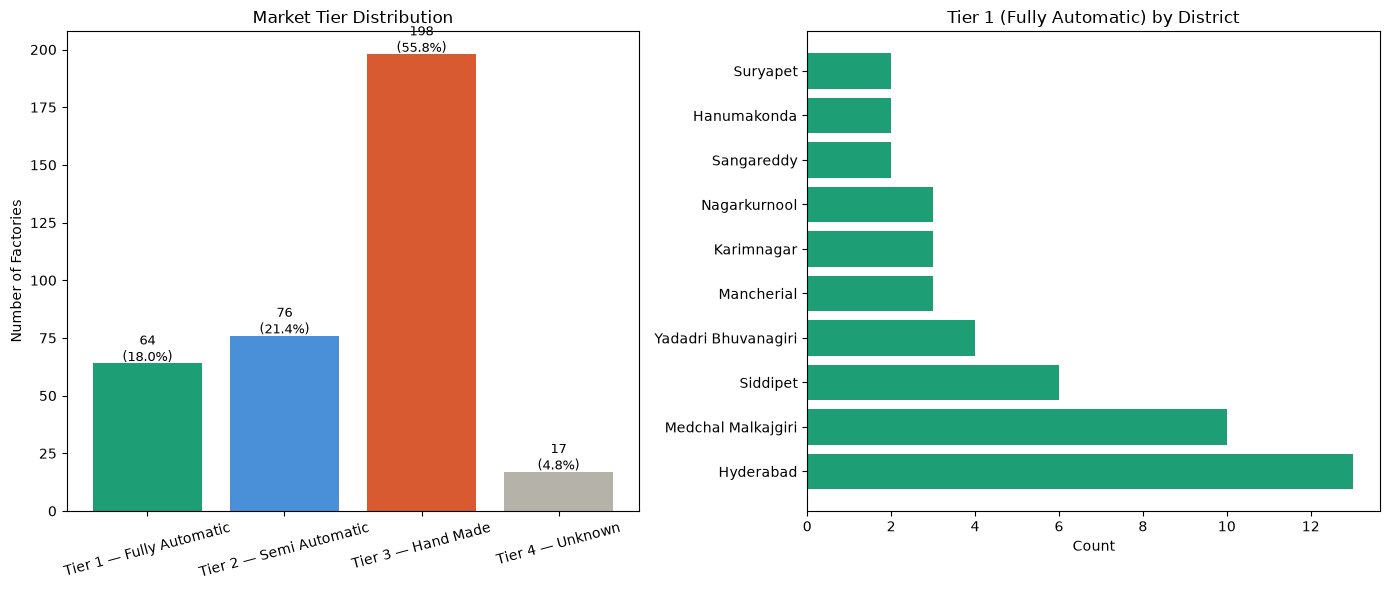

Chart saved ✓


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Tier distribution
tier_colors = ['#1D9E75', '#4A90D9', '#D85A30', '#B4B2A9']
axes[0].bar(tier_summary['competitor_tier'], 
            tier_summary['count'],
            color=tier_colors)
axes[0].set_title('Market Tier Distribution')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Factories')
axes[0].tick_params(axis='x', rotation=15)

for i, (count, pct) in enumerate(zip(tier_summary['count'], tier_summary['pct_of_market'])):
    axes[0].text(i, count + 1, f'{count}\n({pct}%)', 
                ha='center', fontsize=9)

# Chart 2: Tier 1 by district (top 10)
tier1_district = tier1['Districts'].value_counts().head(10)
axes[1].barh(tier1_district.index, tier1_district.values, color='#1D9E75')
axes[1].set_title('Tier 1 (Fully Automatic) by District')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('../reports/competitor_intelligence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✓")

In [6]:
df.to_csv('../data/processed/brick_with_tiers.csv', index=False)
tier_summary.to_csv('../data/processed/competitor_tier_summary.csv', index=False)
print("Exported ✓")

print("\n=== PHASE 8 SUMMARY ===")
print(f"Tier 1 (Fully Automatic): {len(df[df['competitor_tier']=='Tier 1 — Fully Automatic'])} factories — your real competition")
print(f"Tier 2 (Semi Auto): {len(df[df['competitor_tier']=='Tier 2 — Semi Automatic'])} factories — emerging competitors")
print(f"Tier 3 (Hand Made): {len(df[df['competitor_tier']=='Tier 3 — Hand Made'])} factories — vulnerable to disruption")

Exported ✓

=== PHASE 8 SUMMARY ===
Tier 1 (Fully Automatic): 64 factories — your real competition
Tier 2 (Semi Auto): 76 factories — emerging competitors
Tier 3 (Hand Made): 198 factories — vulnerable to disruption
